In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Đọc dữ liệu
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'

# Trích xuất đặc trưng

In [4]:
df = pd.read_csv(file_path)
patient_features = df.groupby('numeric_id').agg({
    'FIX_DURATION': ['mean', 'std', 'max'],
    'FIX_PUPIL': ['mean', 'std'],
    'FIX_X': ['std'], # Độ phân tán theo chiều ngang
    'FIX_Y': ['std'], # Độ phân tán theo chiều dọc
    'label': 'max'    # Giữ lại nhãn thực tế để đối chiếu sau này (không dùng để train)
}).reset_index()

# làm phẳng tên các cột sau khi group

In [5]:
patient_features.columns = ['_'.join(col).strip() if col[1] else col[0] for col in patient_features.columns.values]
print("\nDữ liệu sau khi tổng hợp theo bệnh nhân:")
print(patient_features.head())


Dữ liệu sau khi tổng hợp theo bệnh nhân:
   numeric_id  FIX_DURATION_mean  FIX_DURATION_std  FIX_DURATION_max  \
0           0         280.142489        161.012786              2146   
1           1         356.821370        284.018916              2878   
2           2         266.250326        154.872803              2002   
3           3         256.713135        155.622081              1610   
4           4         349.277564        443.436809              5001   

   FIX_PUPIL_mean  FIX_PUPIL_std   FIX_X_std   FIX_Y_std  label_max  
0     1305.439716     222.807627  228.070281  154.314057          0  
1      987.927406     172.638512  199.500290  136.691128          0  
2      646.970665      99.804322  207.315163  141.670250          0  
3      962.120818     251.181438  239.645477  161.688565          0  
4     1557.387047     212.525608  207.961723  147.397700          0  


# Tách nhãn và đặc trưng để so sánh

In [6]:
features_col = [c for c in patient_features.columns if c not in ['numeric_id', 'label_max']]
X = patient_features[features_col]
y_true = patient_features['label_max']

In [7]:
X = X.fillna(0)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Thử group thành 2 nhóm (n_clusters=2) tương ứng với kỳ vọng 2 nhãn
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [10]:
patient_features['cluster'] = clusters

In [11]:
# 5. Giảm chiều dữ liệu bằng PCA để vẽ biểu đồ (Visualisation)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

patient_features['PCA1'] = X_pca[:, 0]
patient_features['PCA2'] = X_pca[:, 1]

Text(0, 0.5, 'PCA Component 2')

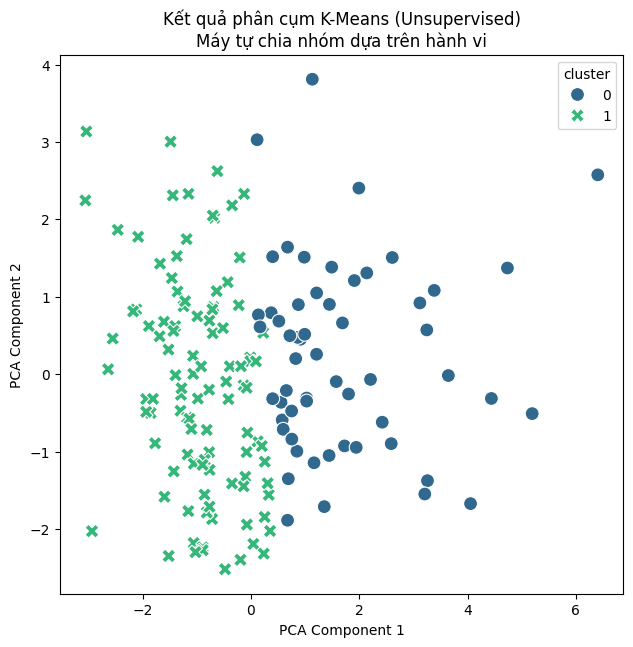

In [12]:
plt.figure(figsize=(16, 7))

# Biểu đồ 1: Kết quả phân cụm của K-Means (Máy tự học)
plt.subplot(1, 2, 1)
sns.scatterplot(data=patient_features, x='PCA1', y='PCA2', hue='cluster', palette='viridis', s=100, style='cluster')
plt.title('Kết quả phân cụm K-Means (Unsupervised)\nMáy tự chia nhóm dựa trên hành vi')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

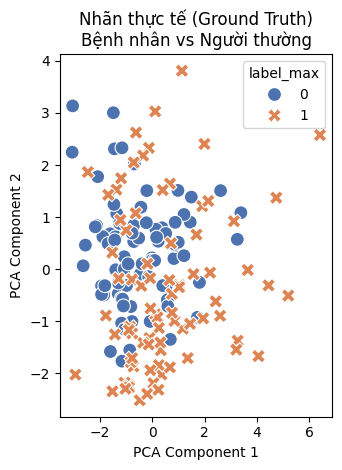

In [13]:
# Biểu đồ 2: Nhãn thực tế (Ground Truth)
plt.subplot(1, 2, 2)
sns.scatterplot(data=patient_features, x='PCA1', y='PCA2', hue='label_max', palette='deep', s=100, style='label_max')
plt.title('Nhãn thực tế (Ground Truth)\nBệnh nhân vs Người thường')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.savefig('clustering_result.png')
plt.show()

In [14]:
# 7. Đánh giá sơ bộ
from sklearn.metrics import confusion_matrix, classification_report
# Lưu ý: K-Means có thể gán nhãn ngược (VD: Nhóm 0 của Kmeans là Nhóm 1 của Label). 
# Ta cần map lại để tính độ chính xác tương đối.
import scipy.stats as stats
mode_map = {}
for i in range(2):
    mask = (patient_features['cluster'] == i)
    # Tìm nhãn thực tế xuất hiện nhiều nhất trong cụm này
    if sum(mask) > 0:
        mode_val = stats.mode(patient_features.loc[mask, 'label_max'])[0]
        # Nếu mode_val là mảng numpy, lấy phần tử đầu tiên
        if isinstance(mode_val, np.ndarray):
            mode_val = mode_val[0]
        mode_map[i] = mode_val
    else:
        mode_map[i] = i

mapped_cluster = patient_features['cluster'].map(mode_map)

print("\n--- Đánh giá hiệu quả gom nhóm so với nhãn gốc ---")
print("Confusion Matrix:")
print(confusion_matrix(y_true, mapped_cluster))
print("\nClassification Report:")
print(classification_report(y_true, mapped_cluster))


--- Đánh giá hiệu quả gom nhóm so với nhãn gốc ---
Confusion Matrix:
[[56 24]
 [47 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.70      0.61        80
           1       0.58      0.41      0.48        80

    accuracy                           0.56       160
   macro avg       0.56      0.56      0.55       160
weighted avg       0.56      0.56      0.55       160

